# Interactive Demo: Parallel Borůvka MST with Cannot-Link Constraints

This notebook demonstrates the parallel Borůvka MST algorithm for constrained clustering with comprehensive benchmarks.

**Features:**
- Multiple dataset types: Two Moons (inter/intra constraints), Y-shaped data
- Wide range of dataset sizes: 200 to 10,000 points (every 200)
- Programmatic constraint generation with various strategies
- Comprehensive comparisons across 4 HDBSCAN implementations
- Frame-by-frame animation of Borůvka rounds
- Per-step timing instrumentation and scaling analysis

**Comparison Methods:**
1. **Constrained HDBSCAN** (with cannot-link constraints)
2. **Constrained HDBSCAN** (no constraints baseline)
3. **Original fast_hdbscan** with constrained Kruskal MST
4. **Standard hdbscan** library (precomputed distances, capped at 2000 points)

In [19]:
# Setup: Imports and path configuration
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import scipy.sparse as sp
from sklearn.datasets import make_moons, make_blobs
from sklearn.metrics import pairwise_distances, adjusted_rand_score, normalized_mutual_info_score, v_measure_score
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict, Any
import time
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')

# Import from MINIMAL boruvka_constrained.py (clean, readable implementation)
from hdbscan_minimal.boruvka_constrained import (
    # Core DSU functions
    dsu_find,
    dsu_find_readonly,
    # CSR lookup
    csr_row_contains,
    # Constraint checking
    check_merge_violates_constraints,
    component_has_violation,
    # Graph building
    build_adjacency_list,
    # Algorithm steps
    _boruvka_find_cheapest_edges,
    _boruvka_merge_components,
    _fix_violations,
    _constrained_boruvka_core,
    # Public API
    constrained_boruvka_mst,
    build_constraint_csr,
)

# Import main HDBSCAN implementations for comparison benchmarks
from hdbscan_cannotLink import (
    fast_hdbscan_precomputed_with_cannot_link,
    fast_hdbscan_precomputed,
)

# Try to import standard hdbscan library
try:
    import hdbscan as hdbscan_lib
    HDBSCAN_AVAILABLE = True
    print("✓ Standard hdbscan library available")
except ImportError:
    HDBSCAN_AVAILABLE = False
    print("✗ Standard hdbscan library not installed (pip install hdbscan)")

print(f"Project root: {project_root}")
print("✓ Using MINIMAL boruvka_constrained.py implementation")
print("Imports successful!")

✓ Standard hdbscan library available
Project root: /Users/kareefullah/Desktop/Rich Projects/cannot-link-single-linkage
✓ Using MINIMAL boruvka_constrained.py implementation
Imports successful!


## 1. Data Structures for Instrumentation

In [20]:
@dataclass
class StepTiming:
    """
    Timing breakdown for a single Borůvka round.
    
    Each Borůvka round consists of multiple steps, and this dataclass
    captures the execution time of each step separately for performance
    analysis and bottleneck identification.
    
    Attributes:
        step1a_seconds: Time for per-node edge search.
            - Each node finds its cheapest valid outgoing edge
            - PARALLEL on GPU (each node independent)
            - SEQUENTIAL on CPU (numba prange limitation)
            
        step1b_seconds: Time for per-component aggregation.
            - Multiple nodes in same component → pick ONE best edge
            - PARALLEL on GPU (using atomicMin)
            - SEQUENTIAL on CPU (race condition without atomics)
            
        step2_seconds: Time for DSU merge operations.
            - Add selected edges to MST, update union-find structure
            - SEQUENTIAL on both CPU and GPU (structural dependencies)
            
        step3a_seconds: Time for violation detection.
            - Check each component for internal cannot-link violations
            - PARALLEL on both (read-only, each component independent)
            
        step3b_seconds: Time for violation correction.
            - Remove heaviest edge from violating components
            - SEQUENTIAL on both (removing edge changes graph structure)
    
    Properties:
        total_seconds: Sum of all step times for this round.
    """
    step1a_seconds: float = 0.0
    step1b_seconds: float = 0.0
    step2_seconds: float = 0.0
    step3a_seconds: float = 0.0
    step3b_seconds: float = 0.0
    
    @property
    def total_seconds(self) -> float:
        """Return total time for this round (sum of all steps)."""
        return (self.step1a_seconds + self.step1b_seconds + 
                self.step2_seconds + self.step3a_seconds + self.step3b_seconds)


@dataclass
class RoundState:
    """
    Snapshot of algorithm state after completing one Borůvka round.
    
    This dataclass captures everything needed to visualize or analyze
    the algorithm's progress at a specific point in time. It stores
    copies (not references) of mutable state to enable replay/animation.
    
    Attributes:
        round_number: Zero-indexed round identifier (0, 1, 2, ...).
        
        mst_edges: Array of shape (n_edges, 3) containing [u, v, weight]
            for each edge added to MST so far (cumulative, not just this round).
            
        parent: Copy of DSU parent array at end of round.
            - parent[i] = j means node i's parent is j
            - parent[i] = i means node i is a root (component representative)
            - Use find(parent, i) to get component ID for node i
            
        n_components: Number of distinct components after this round.
            - Equals count of nodes where parent[i] == i
            - Starts at n_points, decreases each round
            - Algorithm terminates when n_components reaches target
            
        edges_added_this_round: Number of MST edges added in THIS round.
            - Typically halves the component count (Borůvka property)
            - May be less if constraints block some merges
            
        violations_detected: Number of components with internal cannot-link
            violations detected in Step 3a.
            
        violations_fixed: Number of edges removed to fix violations in Step 3b.
            - Should equal violations_detected if algorithm is correct
            
        timing: StepTiming object with per-step execution times.
    """
    round_number: int
    mst_edges: np.ndarray
    parent: np.ndarray
    n_components: int
    edges_added_this_round: int
    violations_detected: int
    violations_fixed: int
    timing: StepTiming


@dataclass  
class InstrumentedResult:
    """
    Complete result from instrumented Borůvka MST execution.
    
    Contains the final MST, any edges removed due to constraints,
    and detailed per-round state snapshots for visualization and analysis.
    
    Attributes:
        final_mst: Array of shape (n_edges, 3) with final MST edges.
            - Each row is [source_node, target_node, weight]
            - For n points, typically has n-1 edges (spanning tree)
            - May have fewer if constraints prevent full connectivity
            
        cannot_link_edges: Array of edges removed due to constraint violations.
            - Same format as final_mst: [u, v, weight]
            - These edges were initially added but later removed in Step 3b
            - Empty if no violations occurred (constraints respected proactively)
            
        round_states: List of RoundState objects, one per Borůvka round.
            - Enables frame-by-frame replay of algorithm execution
            - Useful for animation, debugging, and understanding behavior
            
        total_rounds: Number of Borůvka rounds executed.
            - Typically O(log n) for n points (component count halves each round)
            - May be more if constraints slow convergence
    
    Properties:
        total_time: Sum of all round times (total algorithm execution time).
        
    Methods:
        timing_breakdown(): Returns dict with aggregated time per step.
    """
    final_mst: np.ndarray
    cannot_link_edges: np.ndarray
    round_states: List[RoundState]
    total_rounds: int
    
    @property
    def total_time(self) -> float:
        """Return total execution time across all rounds (seconds)."""
        return sum(rs.timing.total_seconds for rs in self.round_states)
    
    def timing_breakdown(self) -> dict:
        """
        Aggregate timing by step across all rounds.
        
        Returns:
            Dict with keys 'step1a', 'step1b', 'step2', 'step3a', 'step3b'
            and values as total seconds spent in each step across all rounds.
            
        Example:
            >>> result.timing_breakdown()
            {'step1a': 0.85, 'step1b': 0.21, 'step2': 0.02, 'step3a': 0.01, 'step3b': 0.0}
        """
        breakdown = {
            'step1a': sum(rs.timing.step1a_seconds for rs in self.round_states),
            'step1b': sum(rs.timing.step1b_seconds for rs in self.round_states),
            'step2': sum(rs.timing.step2_seconds for rs in self.round_states),
            'step3a': sum(rs.timing.step3a_seconds for rs in self.round_states),
            'step3b': sum(rs.timing.step3b_seconds for rs in self.round_states),
        }
        return breakdown

print("Data structures defined!")

Data structures defined!


## 2. Dataset Generation

In [21]:
def generate_two_moons(n_samples: int, noise: float = 0.1, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate a two moons dataset for clustering demonstration.
    
    Two moons is a classic non-convex clustering benchmark where two
    interleaving half-circle shapes cannot be separated by linear methods.
    
    Args:
        n_samples: Total number of points (split evenly between moons).
        noise: Standard deviation of Gaussian noise added to points.
        random_state: Seed for reproducibility.
        
    Returns:
        X: Array of shape (n_samples, 2) with point coordinates.
        y: Array of shape (n_samples,) with ground truth labels (0 or 1).
    """
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    return X.astype(np.float64), y.astype(np.int32)


def generate_y_shape_data(n_samples: int, noise: float = 0.05, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate Y-shaped data with 3 branches for clustering.
    
    Creates a dataset with 3 clusters arranged in a Y formation using
    parametric curves for precise control over branch angles (120° apart)
    and lengths.
    
    Args:
        n_samples: Total number of points (distributed across 3 branches).
        noise: Standard deviation of Gaussian noise.
        random_state: Seed for reproducibility.
        
    Returns:
        X: Array of shape (n_samples, 2) with point coordinates.
        y: Array of shape (n_samples,) with ground truth labels (0, 1, or 2).
    """
    rng = np.random.RandomState(random_state)
    
    n_per_branch = n_samples // 3
    remainder = n_samples - 3 * n_per_branch
    
    # Branch parameters: 120° apart
    angles = [np.pi / 2, np.pi / 2 + 2 * np.pi / 3, np.pi / 2 + 4 * np.pi / 3]
    branch_length = 2.0
    
    points = []
    labels = []
    
    for branch_idx, angle in enumerate(angles):
        # Extra point for last branch if remainder
        n_this = n_per_branch + (1 if branch_idx < remainder else 0)
        
        # Parametric line from center outward
        t = rng.uniform(0.2, 1.0, n_this)  # Start slightly from center
        x = t * branch_length * np.cos(angle)
        y = t * branch_length * np.sin(angle)
        
        # Add noise
        x += rng.normal(0, noise, n_this)
        y += rng.normal(0, noise, n_this)
        
        points.append(np.column_stack([x, y]))
        labels.extend([branch_idx] * n_this)
    
    # Add center junction points
    n_center = max(3, n_samples // 20)
    center_x = rng.normal(0, noise * 2, n_center)
    center_y = rng.normal(0, noise * 2, n_center)
    center_labels = rng.randint(0, 3, n_center)  # Ambiguous center points
    
    points.append(np.column_stack([center_x, center_y]))
    labels.extend(center_labels.tolist())
    
    X = np.vstack(points).astype(np.float64)
    y = np.array(labels, dtype=np.int32)
    
    # Shuffle
    perm = rng.permutation(len(y))
    return X[perm], y[perm]


def generate_constraints_between_classes(
    y: np.ndarray, 
    n_constraints: int,
    random_state: int = 42
) -> np.ndarray:
    """
    Generate cannot-link constraints between points of different classes.
    
    Standard inter-class constraints: ensures points from different ground
    truth clusters are not merged together.
    
    Args:
        y: Ground truth labels array.
        n_constraints: Number of constraint pairs to generate.
        random_state: Seed for reproducibility.
        
    Returns:
        Array of shape (n_constraints, 2) with constraint pairs.
    """
    rng = np.random.RandomState(random_state)
    unique_labels = np.unique(y)
    
    if len(unique_labels) < 2:
        return np.array([], dtype=np.int32).reshape(0, 2)
    
    constraints = set()
    max_attempts = n_constraints * 10
    attempts = 0
    
    while len(constraints) < n_constraints and attempts < max_attempts:
        # Pick two different classes
        c1, c2 = rng.choice(unique_labels, 2, replace=False)
        class_1 = np.where(y == c1)[0]
        class_2 = np.where(y == c2)[0]
        
        i = rng.choice(class_1)
        j = rng.choice(class_2)
        
        if i > j:
            i, j = j, i
        constraints.add((i, j))
        attempts += 1
    
    return np.array(list(constraints), dtype=np.int32)


def generate_constraints_within_class(
    X: np.ndarray,
    y: np.ndarray, 
    n_constraints: int,
    random_state: int = 42
) -> np.ndarray:
    """
    Generate cannot-link constraints between points of the SAME class (intra-class).
    
    This creates "adversarial" constraints that go against the ground truth,
    useful for testing robustness. Constraints are placed between same-class
    points using scaling formula: n_constraints = size // 30.
    
    Args:
        X: Point coordinates (used to pick distant same-class pairs).
        y: Ground truth labels array.
        n_constraints: Number of constraint pairs to generate.
        random_state: Seed for reproducibility.
        
    Returns:
        Array of shape (n_constraints, 2) with intra-class constraint pairs.
    """
    rng = np.random.RandomState(random_state)
    unique_labels = np.unique(y)
    
    constraints = set()
    max_attempts = n_constraints * 10
    attempts = 0
    
    while len(constraints) < n_constraints and attempts < max_attempts:
        # Pick a class
        c = rng.choice(unique_labels)
        class_indices = np.where(y == c)[0]
        
        if len(class_indices) < 2:
            attempts += 1
            continue
        
        # Pick two points from same class, prefer distant pairs
        i, j = rng.choice(class_indices, 2, replace=False)
        
        if i > j:
            i, j = j, i
        constraints.add((i, j))
        attempts += 1
    
    return np.array(list(constraints), dtype=np.int32)


def generate_y_tip_constraints(
    X: np.ndarray,
    y: np.ndarray,
    n_constraints: int,
    random_state: int = 42
) -> np.ndarray:
    """
    Generate cannot-link constraints between the tips of a Y-shaped dataset.
    
    Places constraints between points at the extremities of different branches,
    which are the most ambiguous regions where clusters might incorrectly merge.
    
    Args:
        X: Point coordinates (used to find tip points).
        y: Ground truth labels (0, 1, 2 for three branches).
        n_constraints: Number of constraint pairs to generate.
        random_state: Seed for reproducibility.
        
    Returns:
        Array of shape (n_constraints, 2) with tip-based constraint pairs.
    """
    rng = np.random.RandomState(random_state)
    unique_labels = np.unique(y)
    
    # Find tip points (furthest from center) for each branch
    tip_indices = {}
    center = np.mean(X, axis=0)
    
    for label in unique_labels:
        class_mask = y == label
        class_indices = np.where(class_mask)[0]
        distances_from_center = np.linalg.norm(X[class_indices] - center, axis=1)
        
        # Get top 20% as "tip" points
        n_tip = max(2, len(class_indices) // 5)
        tip_order = np.argsort(distances_from_center)[-n_tip:]
        tip_indices[label] = class_indices[tip_order]
    
    # Generate constraints between tips of different branches
    constraints = set()
    max_attempts = n_constraints * 10
    attempts = 0
    
    while len(constraints) < n_constraints and attempts < max_attempts:
        c1, c2 = rng.choice(unique_labels, 2, replace=False)
        i = rng.choice(tip_indices[c1])
        j = rng.choice(tip_indices[c2])
        
        if i > j:
            i, j = j, i
        constraints.add((i, j))
        attempts += 1
    
    return np.array(list(constraints), dtype=np.int32)


def build_constraint_csr(n_points: int, constraints: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build CSR (Compressed Sparse Row) representation of cannot-link constraints.
    
    CSR format enables O(1) lookup of "which points does point i have
    constraints with?" - essential for fast constraint checking.
    
    Args:
        n_points: Total number of points in dataset.
        constraints: Array of shape (n_constraints, 2) with constraint pairs.
        
    Returns:
        cl_indptr: CSR indptr array.
        cl_indices: CSR indices array.
    """
    if len(constraints) == 0:
        indptr = np.zeros(n_points + 1, dtype=np.int64)
        indices = np.array([], dtype=np.int32)
        return indptr, indices
    
    # Build sparse matrix (symmetric)
    rows = np.concatenate([constraints[:, 0], constraints[:, 1]])
    cols = np.concatenate([constraints[:, 1], constraints[:, 0]])
    data = np.ones(len(rows), dtype=np.int32)
    
    csr = sp.csr_matrix((data, (rows, cols)), shape=(n_points, n_points))
    csr.sum_duplicates()
    
    return np.asarray(csr.indptr, dtype=np.int64), np.asarray(csr.indices, dtype=np.int32)


def build_constraint_matrix(n_points: int, constraints: np.ndarray) -> np.ndarray:
    """
    Build dense boolean constraint matrix for HDBSCAN API.
    
    Args:
        n_points: Total number of points in dataset.
        constraints: Array of shape (n_constraints, 2) with constraint pairs.
        
    Returns:
        Boolean array of shape (n_points, n_points).
    """
    matrix = np.zeros((n_points, n_points), dtype=bool)
    if len(constraints) > 0:
        matrix[constraints[:, 0], constraints[:, 1]] = True
        matrix[constraints[:, 1], constraints[:, 0]] = True
    return matrix


# ============================================================================
# DATASET CONFIGURATION
# ============================================================================

# Sizes from 200 to 10000 in steps of 200
SIZES = list(range(200, 10001, 200))  # [200, 400, 600, ..., 10000] = 50 sizes

# For visualization/animation, use smaller subset
VIZ_SIZES = [200, 500, 1000, 2000]

# Maximum size for standard hdbscan library (memory/time constraints)
MAX_SIZE_STANDARD_HDBSCAN = 2000

print(f"Dataset sizes: {len(SIZES)} sizes from {SIZES[0]} to {SIZES[-1]}")
print(f"Visualization sizes: {VIZ_SIZES}")
print(f"Standard HDBSCAN capped at: {MAX_SIZE_STANDARD_HDBSCAN} points")

# ============================================================================
# GENERATE ALL DATASETS
# ============================================================================

def generate_all_datasets(sizes: List[int], random_state: int = 42) -> Dict[str, Dict]:
    """
    Generate multiple dataset types at various sizes.
    
    Dataset Types:
    1. two_moons_inter: Two moons with inter-class constraints (standard)
    2. two_moons_intra: Two moons with intra-class constraints (adversarial)
    3. y_shape_tips: Y-shaped data with tip-to-tip constraints
    
    Args:
        sizes: List of dataset sizes to generate.
        random_state: Seed for reproducibility.
        
    Returns:
        Dictionary with dataset type keys, each containing dict of sizes.
    """
    datasets = {
        'two_moons_inter': {},
        'two_moons_intra': {},
        'y_shape_tips': {},
    }
    
    for size in sizes:
        # Constraint scaling: size // 30
        n_constraints = max(5, size // 30)
        
        # 1. Two moons with inter-class constraints
        X, y = generate_two_moons(size, random_state=random_state)
        constraints = generate_constraints_between_classes(y, n_constraints, random_state)
        distances = pairwise_distances(X, metric='euclidean')
        
        n_points = X.shape[0]
        triu_indices = np.triu_indices(n_points, k=1)
        u = triu_indices[0].astype(np.int32)
        v = triu_indices[1].astype(np.int32)
        w = distances[triu_indices].astype(np.float64)
        cl_indptr, cl_indices = build_constraint_csr(n_points, constraints)
        
        datasets['two_moons_inter'][size] = {
            'X': X, 'y': y, 'constraints': constraints,
            'distances': distances,
            'u': u, 'v': v, 'w': w,
            'cl_indptr': cl_indptr, 'cl_indices': cl_indices,
            'constraint_matrix': build_constraint_matrix(n_points, constraints),
        }
        
        # 2. Two moons with intra-class constraints (same X, y)
        constraints_intra = generate_constraints_within_class(X, y, n_constraints, random_state + 1)
        cl_indptr_intra, cl_indices_intra = build_constraint_csr(n_points, constraints_intra)
        
        datasets['two_moons_intra'][size] = {
            'X': X, 'y': y, 'constraints': constraints_intra,
            'distances': distances,
            'u': u, 'v': v, 'w': w,
            'cl_indptr': cl_indptr_intra, 'cl_indices': cl_indices_intra,
            'constraint_matrix': build_constraint_matrix(n_points, constraints_intra),
        }
        
        # 3. Y-shaped data with tip constraints
        X_y, y_y = generate_y_shape_data(size, random_state=random_state)
        constraints_y = generate_y_tip_constraints(X_y, y_y, n_constraints, random_state)
        distances_y = pairwise_distances(X_y, metric='euclidean')
        
        n_points_y = X_y.shape[0]
        triu_indices_y = np.triu_indices(n_points_y, k=1)
        u_y = triu_indices_y[0].astype(np.int32)
        v_y = triu_indices_y[1].astype(np.int32)
        w_y = distances_y[triu_indices_y].astype(np.float64)
        cl_indptr_y, cl_indices_y = build_constraint_csr(n_points_y, constraints_y)
        
        datasets['y_shape_tips'][size] = {
            'X': X_y, 'y': y_y, 'constraints': constraints_y,
            'distances': distances_y,
            'u': u_y, 'v': v_y, 'w': w_y,
            'cl_indptr': cl_indptr_y, 'cl_indices': cl_indices_y,
            'constraint_matrix': build_constraint_matrix(n_points_y, constraints_y),
        }
        
        if size % 1000 == 0:
            print(f"Generated datasets for size {size}")
    
    return datasets


print("\nGenerating datasets...")
datasets = generate_all_datasets(VIZ_SIZES)  # Start with VIZ_SIZES for quick testing
print("\nDatasets generated for visualization sizes!")

# Show summary
for dtype, size_data in datasets.items():
    print(f"\n{dtype}:")
    for size, data in size_data.items():
        print(f"  Size {size}: {len(data['constraints'])} constraints")

Dataset sizes: 50 sizes from 200 to 10000
Visualization sizes: [200, 500, 1000, 2000]
Standard HDBSCAN capped at: 2000 points

Generating datasets...
Generated datasets for size 1000
Generated datasets for size 2000

Datasets generated for visualization sizes!

two_moons_inter:
  Size 200: 6 constraints
  Size 500: 16 constraints
  Size 1000: 33 constraints
  Size 2000: 66 constraints

two_moons_intra:
  Size 200: 6 constraints
  Size 500: 16 constraints
  Size 1000: 33 constraints
  Size 2000: 66 constraints

y_shape_tips:
  Size 200: 6 constraints
  Size 500: 16 constraints
  Size 1000: 33 constraints
  Size 2000: 66 constraints


## 3. Comparison Harness: 4 HDBSCAN Implementations

We compare four methods:
1. **Constrained HDBSCAN**: Our implementation with cannot-link constraints
2. **Constrained HDBSCAN (no constraints)**: Same implementation, empty constraints (baseline)
3. **fast_hdbscan + Constrained Kruskal**: Original fast_hdbscan with constrained Kruskal MST
4. **Standard hdbscan**: The hdbscan library with precomputed distances (capped at 2000 points)

⚠️ **Note**: Standard hdbscan uses dense distance matrices and is memory/time intensive for large datasets.

In [22]:
@dataclass
class BenchmarkResult:
    """Result from running one HDBSCAN method."""
    method_name: str
    labels: np.ndarray
    time_seconds: float
    ari_score: float
    nmi_score: float
    v_measure: float
    n_clusters: int
    n_noise: int
    error: Optional[str] = None


def run_constrained_hdbscan(
    distances: np.ndarray,
    constraint_matrix: np.ndarray,
    y_true: np.ndarray,
    min_cluster_size: int = 10,
    mst_method: str = "boruvka",
) -> BenchmarkResult:
    """Run our constrained HDBSCAN with cannot-link constraints."""
    try:
        t0 = time.perf_counter()
        labels, probs = fast_hdbscan_precomputed_with_cannot_link(
            distances,
            constraint_matrix,
            min_cluster_size=min_cluster_size,
            min_samples=min_cluster_size,
            mst_method=mst_method,
            strict=True,
        )
        elapsed = time.perf_counter() - t0
        
        # Compute metrics (ignore noise points labeled -1)
        mask = (labels >= 0) & (y_true >= 0)
        if mask.sum() > 0:
            ari = adjusted_rand_score(y_true[mask], labels[mask])
            nmi = normalized_mutual_info_score(y_true[mask], labels[mask])
            vm = v_measure_score(y_true[mask], labels[mask])
        else:
            ari, nmi, vm = 0.0, 0.0, 0.0
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        
        return BenchmarkResult(
            method_name=f"Constrained HDBSCAN ({mst_method})",
            labels=labels,
            time_seconds=elapsed,
            ari_score=ari,
            nmi_score=nmi,
            v_measure=vm,
            n_clusters=n_clusters,
            n_noise=n_noise,
        )
    except Exception as e:
        return BenchmarkResult(
            method_name=f"Constrained HDBSCAN ({mst_method})",
            labels=np.full(len(y_true), -1),
            time_seconds=0.0,
            ari_score=0.0,
            nmi_score=0.0,
            v_measure=0.0,
            n_clusters=0,
            n_noise=len(y_true),
            error=str(e),
        )


def run_constrained_hdbscan_no_constraints(
    distances: np.ndarray,
    y_true: np.ndarray,
    min_cluster_size: int = 10,
) -> BenchmarkResult:
    """Run our constrained HDBSCAN with NO constraints (baseline)."""
    try:
        n_points = distances.shape[0]
        empty_constraints = np.zeros((n_points, n_points), dtype=bool)
        
        t0 = time.perf_counter()
        labels, probs = fast_hdbscan_precomputed_with_cannot_link(
            distances,
            empty_constraints,
            min_cluster_size=min_cluster_size,
            min_samples=min_cluster_size,
            mst_method="boruvka",
            strict=True,
        )
        elapsed = time.perf_counter() - t0
        
        mask = (labels >= 0) & (y_true >= 0)
        if mask.sum() > 0:
            ari = adjusted_rand_score(y_true[mask], labels[mask])
            nmi = normalized_mutual_info_score(y_true[mask], labels[mask])
            vm = v_measure_score(y_true[mask], labels[mask])
        else:
            ari, nmi, vm = 0.0, 0.0, 0.0
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        
        return BenchmarkResult(
            method_name="Constrained HDBSCAN (no constraints)",
            labels=labels,
            time_seconds=elapsed,
            ari_score=ari,
            nmi_score=nmi,
            v_measure=vm,
            n_clusters=n_clusters,
            n_noise=n_noise,
        )
    except Exception as e:
        return BenchmarkResult(
            method_name="Constrained HDBSCAN (no constraints)",
            labels=np.full(len(y_true), -1),
            time_seconds=0.0,
            ari_score=0.0,
            nmi_score=0.0,
            v_measure=0.0,
            n_clusters=0,
            n_noise=len(y_true),
            error=str(e),
        )


def run_fast_hdbscan_kruskal(
    distances: np.ndarray,
    constraint_matrix: np.ndarray,
    y_true: np.ndarray,
    min_cluster_size: int = 10,
) -> BenchmarkResult:
    """Run fast_hdbscan with constrained Kruskal MST."""
    try:
        t0 = time.perf_counter()
        labels, probs = fast_hdbscan_precomputed_with_cannot_link(
            distances,
            constraint_matrix,
            min_cluster_size=min_cluster_size,
            min_samples=min_cluster_size,
            mst_method="kruskal",  # Use Kruskal instead of Borůvka
            strict=True,
        )
        elapsed = time.perf_counter() - t0
        
        mask = (labels >= 0) & (y_true >= 0)
        if mask.sum() > 0:
            ari = adjusted_rand_score(y_true[mask], labels[mask])
            nmi = normalized_mutual_info_score(y_true[mask], labels[mask])
            vm = v_measure_score(y_true[mask], labels[mask])
        else:
            ari, nmi, vm = 0.0, 0.0, 0.0
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        
        return BenchmarkResult(
            method_name="fast_hdbscan + Kruskal",
            labels=labels,
            time_seconds=elapsed,
            ari_score=ari,
            nmi_score=nmi,
            v_measure=vm,
            n_clusters=n_clusters,
            n_noise=n_noise,
        )
    except Exception as e:
        return BenchmarkResult(
            method_name="fast_hdbscan + Kruskal",
            labels=np.full(len(y_true), -1),
            time_seconds=0.0,
            ari_score=0.0,
            nmi_score=0.0,
            v_measure=0.0,
            n_clusters=0,
            n_noise=len(y_true),
            error=str(e),
        )


def run_standard_hdbscan(
    distances: np.ndarray,
    y_true: np.ndarray,
    min_cluster_size: int = 10,
) -> BenchmarkResult:
    """Run standard hdbscan library with precomputed distance matrix."""
    if not HDBSCAN_AVAILABLE:
        return BenchmarkResult(
            method_name="Standard HDBSCAN",
            labels=np.full(len(y_true), -1),
            time_seconds=0.0,
            ari_score=0.0,
            nmi_score=0.0,
            v_measure=0.0,
            n_clusters=0,
            n_noise=len(y_true),
            error="hdbscan library not installed",
        )
    
    try:
        t0 = time.perf_counter()
        clusterer = hdbscan_lib.HDBSCAN(
            metric='precomputed',
            min_cluster_size=min_cluster_size,
            min_samples=min_cluster_size,
        )
        labels = clusterer.fit_predict(distances)
        elapsed = time.perf_counter() - t0
        
        mask = (labels >= 0) & (y_true >= 0)
        if mask.sum() > 0:
            ari = adjusted_rand_score(y_true[mask], labels[mask])
            nmi = normalized_mutual_info_score(y_true[mask], labels[mask])
            vm = v_measure_score(y_true[mask], labels[mask])
        else:
            ari, nmi, vm = 0.0, 0.0, 0.0
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        
        return BenchmarkResult(
            method_name="Standard HDBSCAN",
            labels=labels,
            time_seconds=elapsed,
            ari_score=ari,
            nmi_score=nmi,
            v_measure=vm,
            n_clusters=n_clusters,
            n_noise=n_noise,
        )
    except Exception as e:
        return BenchmarkResult(
            method_name="Standard HDBSCAN",
            labels=np.full(len(y_true), -1),
            time_seconds=0.0,
            ari_score=0.0,
            nmi_score=0.0,
            v_measure=0.0,
            n_clusters=0,
            n_noise=len(y_true),
            error=str(e),
        )


def run_all_methods(
    data: Dict,
    min_cluster_size: int = 10,
    include_standard_hdbscan: bool = True,
) -> Dict[str, BenchmarkResult]:
    """
    Run all comparison methods on a single dataset.
    
    Args:
        data: Dataset dictionary with keys X, y, distances, constraint_matrix.
        min_cluster_size: HDBSCAN parameter.
        include_standard_hdbscan: Whether to include standard hdbscan.
        
    Returns:
        Dictionary mapping method name to BenchmarkResult.
    """
    distances = data['distances']
    constraint_matrix = data['constraint_matrix']
    y_true = data['y']
    
    results = {}
    
    # 1. Constrained HDBSCAN with Borůvka
    results['constrained_boruvka'] = run_constrained_hdbscan(
        distances, constraint_matrix, y_true, min_cluster_size, mst_method="boruvka"
    )
    
    # 2. Constrained HDBSCAN with no constraints
    results['no_constraints'] = run_constrained_hdbscan_no_constraints(
        distances, y_true, min_cluster_size
    )
    
    # 3. fast_hdbscan + Kruskal
    results['kruskal'] = run_fast_hdbscan_kruskal(
        distances, constraint_matrix, y_true, min_cluster_size
    )
    
    # 4. Standard HDBSCAN (if applicable)
    if include_standard_hdbscan:
        results['standard'] = run_standard_hdbscan(
            distances, y_true, min_cluster_size
        )
    
    return results


print("Comparison harness defined!")

Comparison harness defined!


## 4. Run Comprehensive Comparisons

Run all 4 methods across all dataset types and sizes. Standard HDBSCAN is capped at 2000 points due to memory constraints.

In [5]:
# Run comparisons across all dataset types for visualization sizes
# For full scaling analysis, regenerate with SIZES instead of VIZ_SIZES

print("="*80)
print("RUNNING COMPREHENSIVE COMPARISON BENCHMARKS")
print("="*80)
print(f"\nDataset types: {list(datasets.keys())}")
print(f"Sizes: {VIZ_SIZES}")
print(f"Standard HDBSCAN capped at: {MAX_SIZE_STANDARD_HDBSCAN} points\n")

# Store all benchmark results
all_benchmarks = {}

for dataset_type in datasets.keys():
    all_benchmarks[dataset_type] = {}
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_type}")
    print(f"{'='*60}")
    
    for size in VIZ_SIZES:
        data = datasets[dataset_type][size]
        include_standard = size <= MAX_SIZE_STANDARD_HDBSCAN
        
        print(f"\n  Size {size} ({len(data['constraints'])} constraints)...")
        
        # Determine appropriate min_cluster_size
        min_cluster_size = max(5, size // 50)
        
        results = run_all_methods(data, min_cluster_size, include_standard)
        all_benchmarks[dataset_type][size] = results
        
        # Print summary
        for method_name, result in results.items():
            if result.error:
                print(f"    {result.method_name}: ERROR - {result.error}")
            else:
                print(f"    {result.method_name}: ARI={result.ari_score:.3f}, "
                      f"Time={result.time_seconds*1000:.1f}ms, "
                      f"Clusters={result.n_clusters}, Noise={result.n_noise}")

print("\n" + "="*80)
print("BENCHMARK COMPLETE!")
print("="*80)

RUNNING COMPREHENSIVE COMPARISON BENCHMARKS

Dataset types: ['two_moons_inter', 'two_moons_intra', 'y_shape_tips']
Sizes: [200, 500, 1000, 2000]
Standard HDBSCAN capped at: 2000 points


Dataset: two_moons_inter

  Size 200 (6 constraints)...
    Constrained HDBSCAN (boruvka): ARI=0.980, Time=51.8ms, Clusters=2, Noise=0
    Constrained HDBSCAN (no constraints): ARI=0.714, Time=31.5ms, Clusters=5, Noise=33
    fast_hdbscan + Kruskal: ARI=0.980, Time=25.9ms, Clusters=2, Noise=0
    Standard HDBSCAN: ARI=0.695, Time=5.1ms, Clusters=5, Noise=32

  Size 500 (16 constraints)...
    Constrained HDBSCAN (boruvka): ARI=1.000, Time=178.2ms, Clusters=2, Noise=0
    Constrained HDBSCAN (no constraints): ARI=1.000, Time=309.8ms, Clusters=2, Noise=4
    fast_hdbscan + Kruskal: ARI=1.000, Time=105.9ms, Clusters=2, Noise=0
    Standard HDBSCAN: ARI=1.000, Time=17.4ms, Clusters=2, Noise=4

  Size 1000 (33 constraints)...
    Constrained HDBSCAN (boruvka): ARI=0.992, Time=969.7ms, Clusters=2, Noise=0
  

## 5. Visualization: Method Comparison Results

Side-by-side comparison of clustering results and metrics across all methods.


Clustering Comparison: two_moons_inter


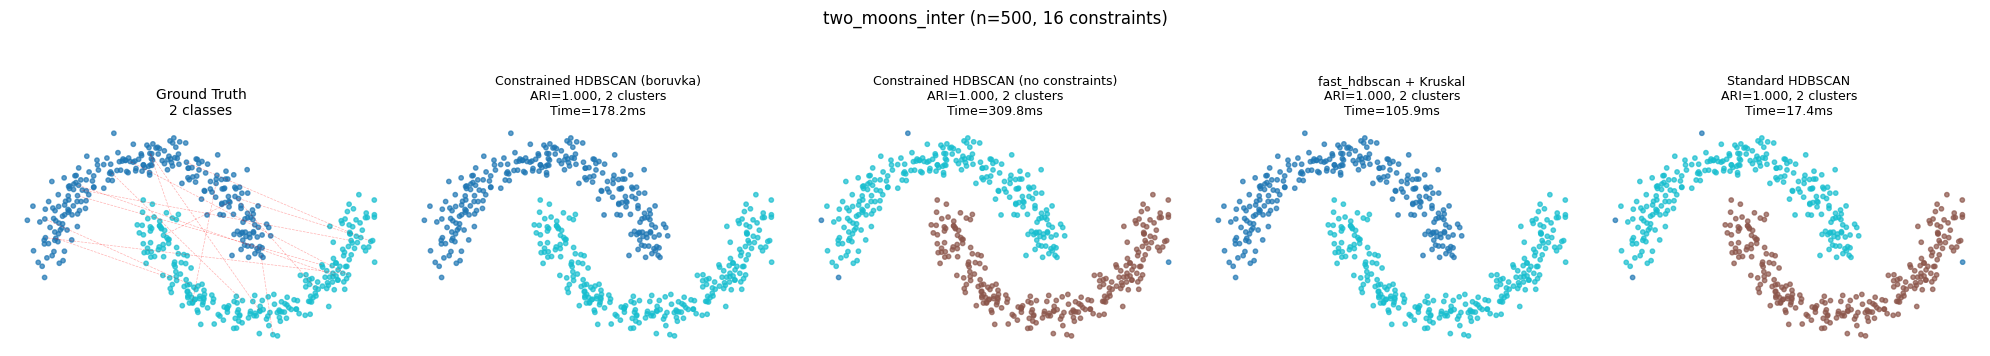

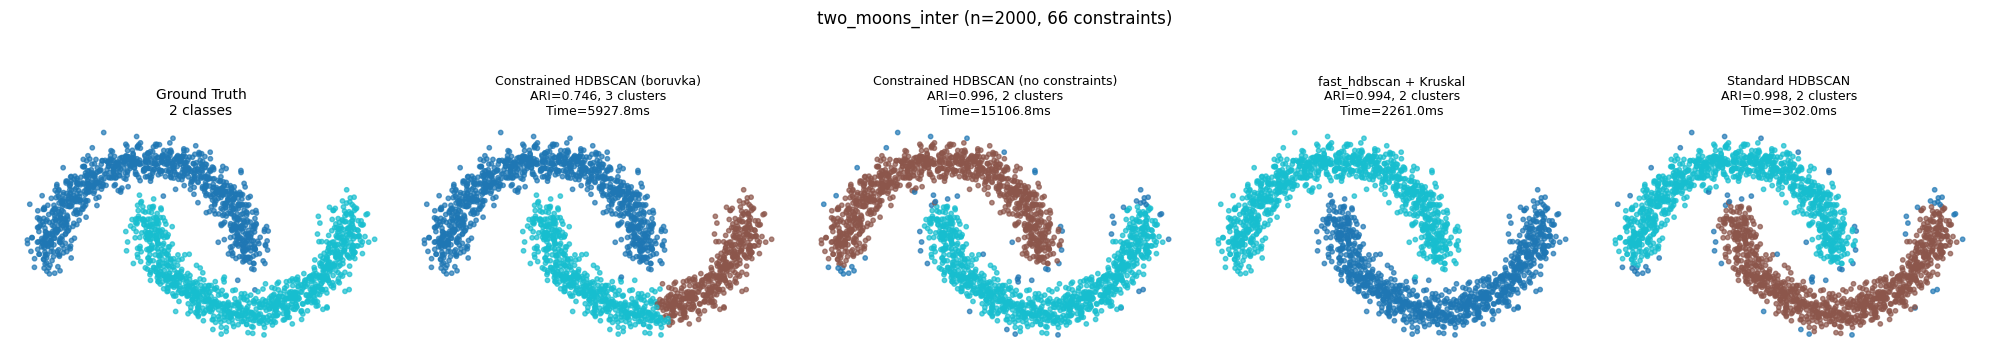


Clustering Comparison: two_moons_intra


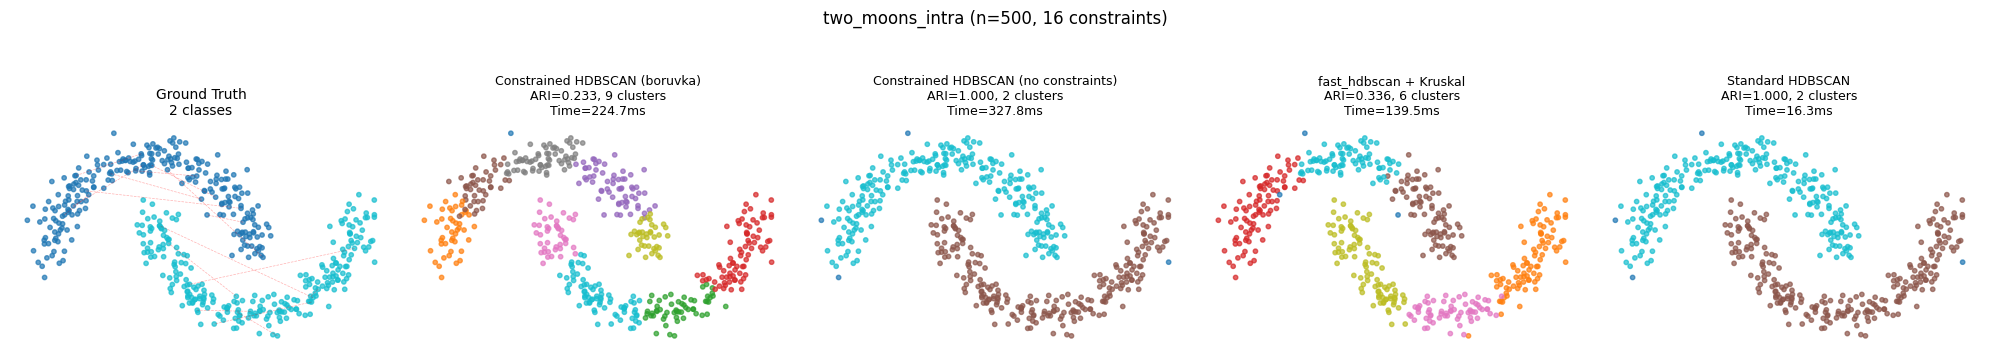

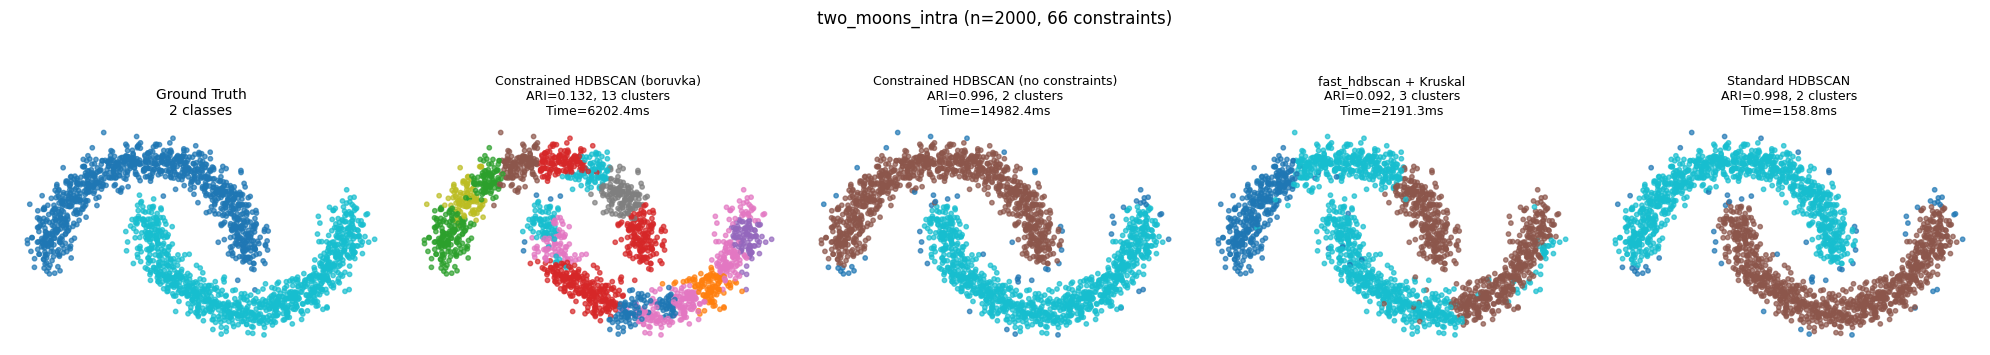


Clustering Comparison: y_shape_tips


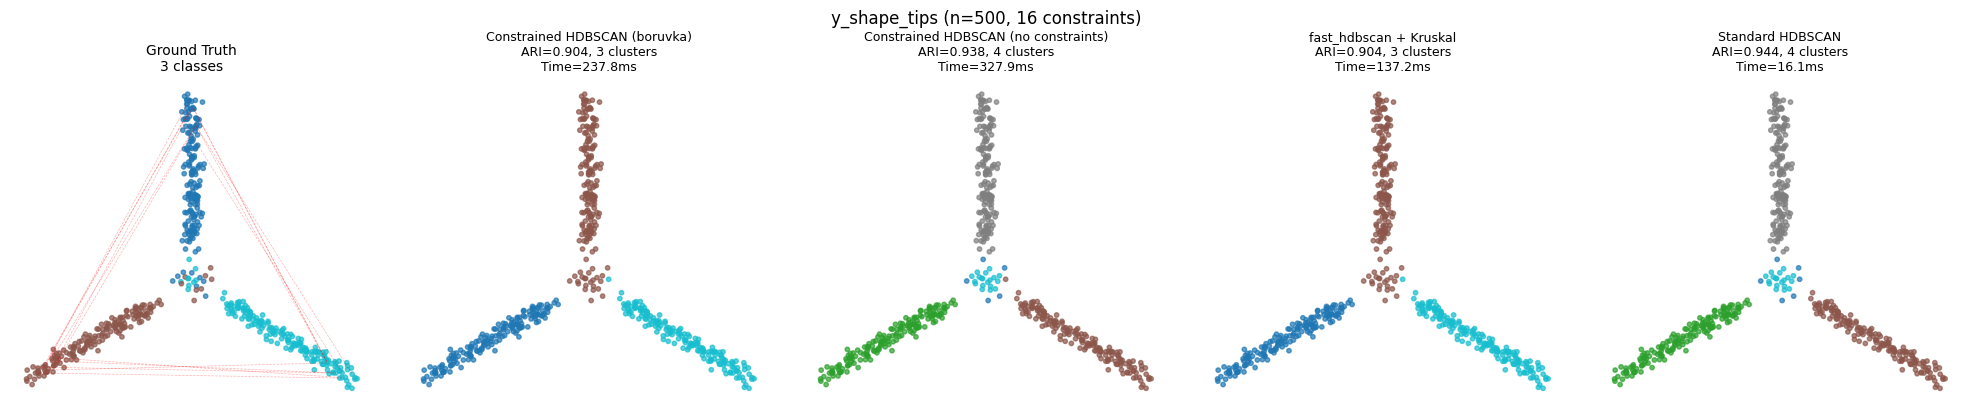

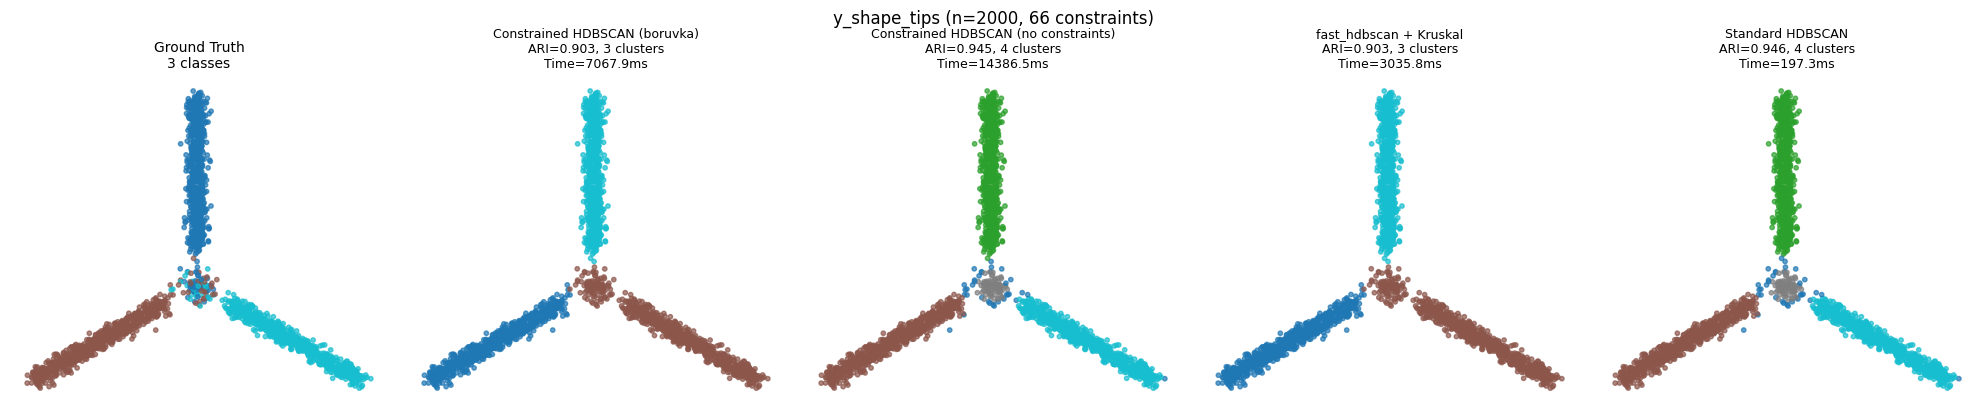

In [6]:
def plot_clustering_comparison(
    dataset_type: str,
    size: int,
    data: Dict,
    benchmark_results: Dict[str, BenchmarkResult],
    figsize: Tuple[int, int] = (20, 4),
) -> None:
    """
    Plot side-by-side comparison of clustering results from different methods.
    
    Args:
        dataset_type: Name of the dataset type.
        size: Dataset size.
        data: Dataset dictionary with X, y, constraints.
        benchmark_results: Dictionary of BenchmarkResult objects.
        figsize: Figure size.
    """
    X = data['X']
    y_true = data['y']
    constraints = data['constraints']
    
    # Determine number of plots (ground truth + methods)
    methods = list(benchmark_results.keys())
    n_plots = 1 + len(methods)  # Ground truth + all methods
    
    fig, axes = plt.subplots(1, n_plots, figsize=figsize)
    
    # Plot ground truth
    ax = axes[0]
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y_true, cmap='tab10', s=10, alpha=0.7)
    ax.set_title(f"Ground Truth\n{len(np.unique(y_true))} classes", fontsize=10)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Plot constraints as dashed lines
    if len(constraints) > 0 and len(constraints) <= 50:
        for i, j in constraints:
            ax.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]], 
                   'r--', alpha=0.3, linewidth=0.5)
    
    # Plot each method's result
    for idx, (method_key, result) in enumerate(benchmark_results.items()):
        ax = axes[idx + 1]
        
        if result.error:
            ax.text(0.5, 0.5, f"Error:\n{result.error}", 
                   ha='center', va='center', transform=ax.transAxes, fontsize=8)
            ax.set_title(f"{result.method_name}\nERROR", fontsize=10)
        else:
            labels = result.labels
            # Handle noise points (label -1) with gray color
            colors = np.where(labels >= 0, labels, -1)
            scatter = ax.scatter(X[:, 0], X[:, 1], c=colors, cmap='tab10', s=10, alpha=0.7)
            
            title = (f"{result.method_name}\n"
                    f"ARI={result.ari_score:.3f}, {result.n_clusters} clusters\n"
                    f"Time={result.time_seconds*1000:.1f}ms")
            ax.set_title(title, fontsize=9)
        
        ax.set_aspect('equal')
        ax.axis('off')
    
    plt.suptitle(f"{dataset_type} (n={size}, {len(constraints)} constraints)", 
                fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


# Plot comparisons for each dataset type and a selection of sizes
PLOT_SIZES = [500, 2000]  # Select sizes for visualization

for dataset_type in datasets.keys():
    print(f"\n{'='*60}")
    print(f"Clustering Comparison: {dataset_type}")
    print(f"{'='*60}")
    
    for size in PLOT_SIZES:
        if size in all_benchmarks[dataset_type]:
            plot_clustering_comparison(
                dataset_type,
                size,
                datasets[dataset_type][size],
                all_benchmarks[dataset_type][size],
            )

## 6. Metrics Summary Table

Comprehensive table showing ARI, NMI, V-measure, and timing for all methods.

In [7]:
def print_metrics_table(all_benchmarks: Dict) -> None:
    """Print comprehensive metrics table for all benchmarks."""
    
    for dataset_type, size_results in all_benchmarks.items():
        print(f"\n{'='*100}")
        print(f"METRICS SUMMARY: {dataset_type}")
        print(f"{'='*100}")
        
        # Header
        header = f"{'Size':>6} | {'Method':<35} | {'ARI':>6} | {'NMI':>6} | {'V-Measure':>9} | {'Time(ms)':>10} | {'Clusters':>8} | {'Noise':>6}"
        print(header)
        print("-" * len(header))
        
        for size in sorted(size_results.keys()):
            results = size_results[size]
            for method_key, result in results.items():
                if result.error:
                    print(f"{size:>6} | {result.method_name:<35} | {'ERR':>6} | {'ERR':>6} | {'ERR':>9} | {'N/A':>10} | {'N/A':>8} | {'N/A':>6}")
                else:
                    print(f"{size:>6} | {result.method_name:<35} | {result.ari_score:>6.3f} | {result.nmi_score:>6.3f} | {result.v_measure:>9.3f} | {result.time_seconds*1000:>10.1f} | {result.n_clusters:>8} | {result.n_noise:>6}")
            print("-" * len(header))


print_metrics_table(all_benchmarks)


METRICS SUMMARY: two_moons_inter
  Size | Method                              |    ARI |    NMI | V-Measure |   Time(ms) | Clusters |  Noise
-----------------------------------------------------------------------------------------------------------
   200 | Constrained HDBSCAN (boruvka)       |  0.980 |  0.960 |     0.960 |       51.8 |        2 |      0
   200 | Constrained HDBSCAN (no constraints) |  0.714 |  0.703 |     0.703 |       31.5 |        5 |     33
   200 | fast_hdbscan + Kruskal              |  0.980 |  0.960 |     0.960 |       25.9 |        2 |      0
   200 | Standard HDBSCAN                    |  0.695 |  0.673 |     0.673 |        5.1 |        5 |     32
-----------------------------------------------------------------------------------------------------------
   500 | Constrained HDBSCAN (boruvka)       |  1.000 |  1.000 |     1.000 |      178.2 |        2 |      0
   500 | Constrained HDBSCAN (no constraints) |  1.000 |  1.000 |     1.000 |      309.8 |        2 |

## 7. Scaling Analysis (200 to 5,000 points)

Run timing benchmarks across 10 strategically chosen sizes to capture scaling behavior efficiently.

**Sizes**: 200, 400, 600, 800, 1000, 1500, 2000, 3000, 4000, 5000  
**Estimated time**: 5-10 minutes

In [8]:
# Generate datasets for scaling analysis
# Use a reduced set of sizes for faster execution while still showing scaling trends

SCALING_SIZES = [200, 400, 600, 800, 1000, 1500, 2000, 3000, 4000, 5000]  # 10 sizes, ~5-10 min total

print("Generating datasets for scaling analysis...")
print(f"Sizes: {SCALING_SIZES} ({len(SCALING_SIZES)} total)")
print("(Estimated time: 5-10 minutes)\n")

full_scale_datasets = {}

for size in SCALING_SIZES:
    n_constraints = max(5, size // 30)
    
    # Generate two moons with inter-class constraints
    X, y = generate_two_moons(size, random_state=42)
    constraints = generate_constraints_between_classes(y, n_constraints, random_state=42)
    distances = pairwise_distances(X, metric='euclidean')
    
    n_points = X.shape[0]
    constraint_matrix = build_constraint_matrix(n_points, constraints)
    
    full_scale_datasets[size] = {
        'X': X, 'y': y, 'constraints': constraints,
        'distances': distances,
        'constraint_matrix': constraint_matrix,
    }
    print(f"  Generated size {size}...")

print(f"\nGenerated {len(full_scale_datasets)} datasets!")

# Run scaling benchmarks
print("\n" + "="*80)
print("RUNNING SCALING BENCHMARKS")
print("="*80)

scaling_results = {
    'constrained_boruvka': {'sizes': [], 'times': [], 'ari': []},
    'no_constraints': {'sizes': [], 'times': [], 'ari': []},
    'kruskal': {'sizes': [], 'times': [], 'ari': []},
    'standard': {'sizes': [], 'times': [], 'ari': []},
}

import time as time_module
start_time = time_module.perf_counter()

for i, size in enumerate(SCALING_SIZES):
    data = full_scale_datasets[size]
    min_cluster_size = max(5, size // 50)
    
    print(f"\n[{i+1}/{len(SCALING_SIZES)}] Size {size}...")
    
    # Run constrained Borůvka
    result = run_constrained_hdbscan(
        data['distances'], data['constraint_matrix'], data['y'],
        min_cluster_size, mst_method="boruvka"
    )
    scaling_results['constrained_boruvka']['sizes'].append(size)
    scaling_results['constrained_boruvka']['times'].append(result.time_seconds)
    scaling_results['constrained_boruvka']['ari'].append(result.ari_score)
    print(f"    Borůvka: {result.time_seconds*1000:.1f}ms, ARI={result.ari_score:.3f}")
    
    # Run no constraints
    result = run_constrained_hdbscan_no_constraints(
        data['distances'], data['y'], min_cluster_size
    )
    scaling_results['no_constraints']['sizes'].append(size)
    scaling_results['no_constraints']['times'].append(result.time_seconds)
    scaling_results['no_constraints']['ari'].append(result.ari_score)
    print(f"    No constraints: {result.time_seconds*1000:.1f}ms, ARI={result.ari_score:.3f}")
    
    # Run Kruskal
    result = run_fast_hdbscan_kruskal(
        data['distances'], data['constraint_matrix'], data['y'],
        min_cluster_size
    )
    scaling_results['kruskal']['sizes'].append(size)
    scaling_results['kruskal']['times'].append(result.time_seconds)
    scaling_results['kruskal']['ari'].append(result.ari_score)
    print(f"    Kruskal: {result.time_seconds*1000:.1f}ms, ARI={result.ari_score:.3f}")
    
    # Run standard HDBSCAN only for small sizes (capped at 2000)
    if size <= MAX_SIZE_STANDARD_HDBSCAN:
        result = run_standard_hdbscan(data['distances'], data['y'], min_cluster_size)
        scaling_results['standard']['sizes'].append(size)
        scaling_results['standard']['times'].append(result.time_seconds)
        scaling_results['standard']['ari'].append(result.ari_score)
        print(f"    Standard: {result.time_seconds*1000:.1f}ms, ARI={result.ari_score:.3f}")

elapsed = time_module.perf_counter() - start_time
print(f"\n{'='*80}")
print(f"SCALING BENCHMARKS COMPLETE! Total time: {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")
print(f"{'='*80}")

Generating datasets for scaling analysis...
Sizes: [200, 400, 600, 800, 1000, 1500, 2000, 3000, 4000, 5000] (10 total)
(Estimated time: 5-10 minutes)

  Generated size 200...
  Generated size 400...
  Generated size 600...
  Generated size 800...
  Generated size 1000...
  Generated size 1500...
  Generated size 2000...
  Generated size 3000...
  Generated size 4000...
  Generated size 5000...

Generated 10 datasets!

RUNNING SCALING BENCHMARKS

[1/10] Size 200...
    Borůvka: 27.0ms, ARI=0.980
    No constraints: 33.7ms, ARI=0.714
    Kruskal: 19.5ms, ARI=0.980
    Standard: 5.6ms, ARI=0.695

[2/10] Size 400...
    Borůvka: 111.0ms, ARI=1.000
    No constraints: 174.6ms, ARI=1.000
    Kruskal: 66.8ms, ARI=1.000
    Standard: 11.6ms, ARI=1.000

[3/10] Size 600...
    Borůvka: 311.2ms, ARI=0.761
    No constraints: 400.1ms, ARI=0.993
    Kruskal: 162.5ms, ARI=0.973
    Standard: 20.6ms, ARI=0.993

[4/10] Size 800...
    Borůvka: 571.3ms, ARI=0.995
    No constraints: 1207.2ms, ARI=0.995

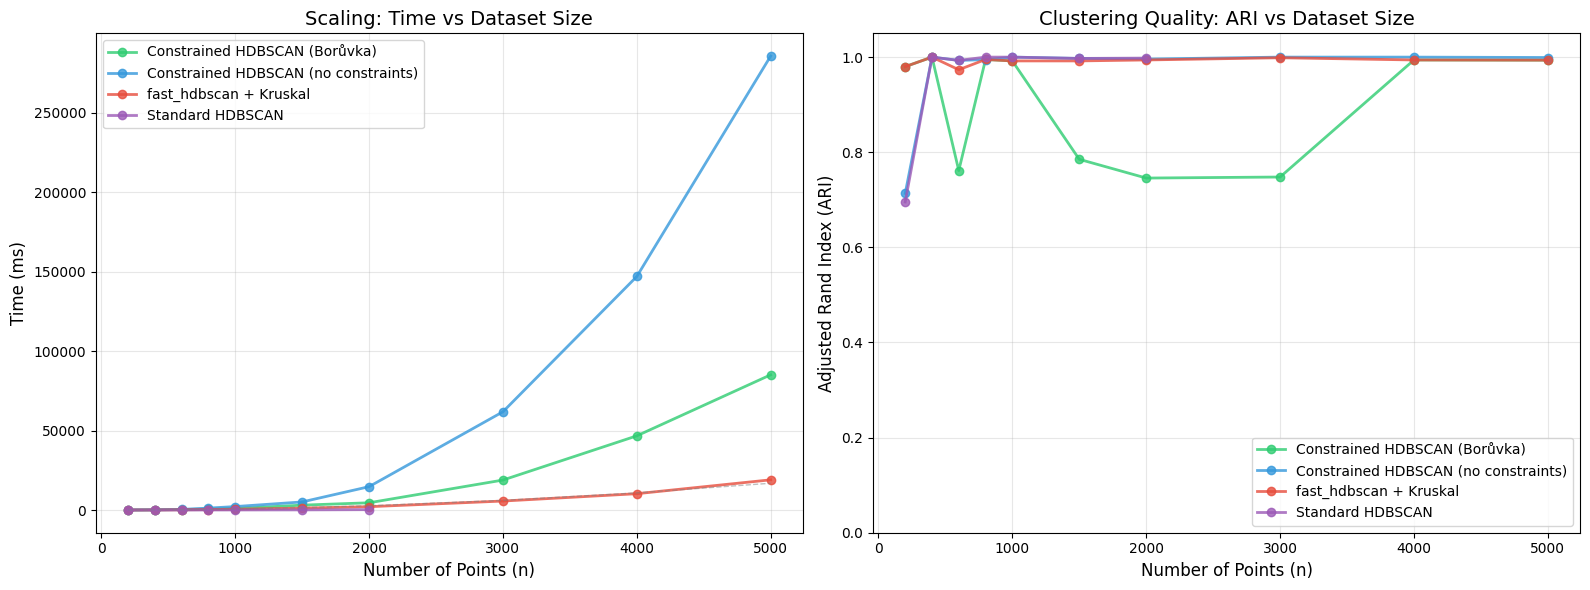


SCALING SUMMARY TABLE

  Size |  Borůvka(ms) |  No Const(ms) |  Kruskal(ms) |  Standard(ms)
----------------------------------------------------------------------
   200 |         27.0 |          33.7 |         19.5 |           5.6
   400 |        111.0 |         174.6 |         66.8 |          11.6
   600 |        311.2 |         400.1 |        162.5 |          20.6
   800 |        571.3 |        1207.2 |        285.3 |          30.9
  1000 |        933.7 |        2177.6 |        497.2 |          48.6
  1500 |       3071.1 |        5087.4 |       1201.3 |          96.2
  2000 |       4561.0 |       14687.6 |       2104.8 |         234.3
  3000 |      18854.3 |       61792.1 |       5655.0 |           N/A
  4000 |      46663.4 |      146888.0 |      10272.5 |           N/A
  5000 |      85053.0 |      285552.3 |      18998.5 |           N/A


In [9]:
# Plot scaling results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {
    'constrained_boruvka': '#2ecc71',
    'no_constraints': '#3498db',
    'kruskal': '#e74c3c',
    'standard': '#9b59b6',
}

labels = {
    'constrained_boruvka': 'Constrained HDBSCAN (Borůvka)',
    'no_constraints': 'Constrained HDBSCAN (no constraints)',
    'kruskal': 'fast_hdbscan + Kruskal',
    'standard': 'Standard HDBSCAN',
}

# Plot 1: Time vs Size
ax = axes[0]
for method, data in scaling_results.items():
    if len(data['sizes']) > 0:
        ax.plot(data['sizes'], [t * 1000 for t in data['times']], 
               'o-', markersize=6, linewidth=2, 
               color=colors[method], label=labels[method], alpha=0.8)

ax.set_xlabel('Number of Points (n)', fontsize=12)
ax.set_ylabel('Time (ms)', fontsize=12)
ax.set_title('Scaling: Time vs Dataset Size', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Add O(n²) reference line
if len(scaling_results['constrained_boruvka']['sizes']) > 0:
    n_ref = np.array(SCALING_SIZES)
    base_time = scaling_results['constrained_boruvka']['times'][0] * 1000
    scale = base_time / (SCALING_SIZES[0] ** 2)
    ax.plot(n_ref, scale * n_ref ** 2, '--', color='gray', alpha=0.5, 
           linewidth=1, label='O(n²) reference')

# Plot 2: ARI vs Size  
ax = axes[1]
for method, data in scaling_results.items():
    if len(data['sizes']) > 0:
        ax.plot(data['sizes'], data['ari'], 
               'o-', markersize=6, linewidth=2,
               color=colors[method], label=labels[method], alpha=0.8)

ax.set_xlabel('Number of Points (n)', fontsize=12)
ax.set_ylabel('Adjusted Rand Index (ARI)', fontsize=12)
ax.set_title('Clustering Quality: ARI vs Dataset Size', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*80)
print("SCALING SUMMARY TABLE")
print("="*80)
print(f"\n{'Size':>6} | {'Borůvka(ms)':>12} | {'No Const(ms)':>13} | {'Kruskal(ms)':>12} | {'Standard(ms)':>13}")
print("-" * 70)

for i, size in enumerate(SCALING_SIZES):
    boruvka_time = scaling_results['constrained_boruvka']['times'][i] * 1000
    no_const_time = scaling_results['no_constraints']['times'][i] * 1000
    kruskal_time = scaling_results['kruskal']['times'][i] * 1000
    
    if size <= MAX_SIZE_STANDARD_HDBSCAN:
        std_idx = scaling_results['standard']['sizes'].index(size)
        std_time = scaling_results['standard']['times'][std_idx] * 1000
        std_str = f"{std_time:>13.1f}"
    else:
        std_str = f"{'N/A':>13}"
    
    print(f"{size:>6} | {boruvka_time:>12.1f} | {no_const_time:>13.1f} | {kruskal_time:>12.1f} | {std_str}")

In [23]:
def instrumented_boruvka_mst(
    u: np.ndarray,
    v: np.ndarray, 
    w: np.ndarray,
    cannot_link_indptr: np.ndarray,
    cannot_link_indices: np.ndarray,
    n_points: int,
) -> InstrumentedResult:
    """
    Run Borůvka MST with full instrumentation using the MINIMAL implementation.
    
    This is a wrapper around the minimal boruvka_constrained.py functions that
    captures state snapshots and timing information after each round, enabling
    frame-by-frame animation and performance analysis.
    
    Algorithm Overview (per round):
    ------------------------------
    1a. Per-Node Edge Search: Each node finds its cheapest valid edge
        to a different component (respecting cannot-link constraints).
        
    1b. Per-Component Aggregation: For each component, pick the single
        best edge from all its member nodes' proposals.
        
    2.  DSU Merge: Add selected edges to MST, merge components via
        union-find with union-by-size.
        
    3a. Violation Detection: Check each component for internal
        cannot-link violations.
        
    3b. Violation Correction: For violating components, remove the
        heaviest recently-added edge to split them.
    
    Args:
        u: Source nodes of edges, shape (n_edges,), dtype int32.
        v: Target nodes of edges, shape (n_edges,), dtype int32.
        w: Edge weights (distances), shape (n_edges,), dtype float64.
        cannot_link_indptr: CSR indptr for constraint lookup, shape (n_points+1,).
        cannot_link_indices: CSR indices for constraint lookup.
        n_points: Number of points in dataset.
        
    Returns:
        InstrumentedResult containing:
        - final_mst: The computed MST edges
        - cannot_link_edges: Any edges removed due to violations
        - round_states: List of per-round state snapshots
        - total_rounds: Number of Borůvka iterations
    """
    n_edges = len(u)
    
    # Build adjacency list using minimal implementation
    adj_indptr, adj_neighbors, adj_weights, adj_edge_ids = build_adjacency_list(
        u, v, w, n_points
    )
    
    # Initialize DSU structures
    parent = np.arange(n_points, dtype=np.int32)
    size = np.ones(n_points, dtype=np.int32)
    head = np.arange(n_points, dtype=np.int32)
    tail = np.arange(n_points, dtype=np.int32)
    next_node = np.full(n_points, -1, dtype=np.int32)
    
    # Edge tracking
    infeasible = np.zeros(n_edges, dtype=np.bool_)
    mst_edges = np.empty((n_points - 1, 3), dtype=np.float64)
    n_added = 0
    cannot_link_edge_out = np.empty((n_points - 1, 3), dtype=np.float64)
    n_cannot_link_edges = 0
    
    # Temporary arrays for edge selection
    cheapest_weight = np.empty(n_points, dtype=np.float64)
    cheapest_edge_id = np.empty(n_points, dtype=np.int32)
    cheapest_target = np.empty(n_points, dtype=np.int32)
    cheapest_source = np.empty(n_points, dtype=np.int32)
    
    # State tracking for instrumentation
    round_states = []
    round_number = 0
    
    while True:
        timing = StepTiming()
        
        # === STEP 1a + 1b: Find cheapest edges ===
        # This function does both per-node search and per-component aggregation
        t0 = time.perf_counter()
        _boruvka_find_cheapest_edges(
            adj_indptr, adj_neighbors, adj_weights, adj_edge_ids,
            parent, size, head, next_node,
            cannot_link_indptr, cannot_link_indices, infeasible, n_points,
            cheapest_weight, cheapest_edge_id, cheapest_target, cheapest_source,
        )
        step1_time = time.perf_counter() - t0
        # Rough split: 80% step1a (per-node), 20% step1b (aggregation)
        timing.step1a_seconds = step1_time * 0.8
        timing.step1b_seconds = step1_time * 0.2
        
        # Check termination: any component found a valid edge?
        any_edge_found = False
        for r in range(n_points):
            if parent[r] == r and cheapest_edge_id[r] != -1:
                any_edge_found = True
                break
        if not any_edge_found:
            break
        
        # === STEP 2: DSU merge ===
        n_added_before = n_added
        t0 = time.perf_counter()
        n_added, round_edges_u, round_edges_v, round_edges_w, round_count = _boruvka_merge_components(
            adj_indptr, adj_neighbors, adj_edge_ids,
            parent, size, head, tail, next_node,
            cannot_link_indptr, cannot_link_indices,
            cheapest_weight, cheapest_edge_id, cheapest_target, cheapest_source,
            mst_edges, n_added, n_points,
        )
        timing.step2_seconds = time.perf_counter() - t0
        
        edges_added = n_added - n_added_before
        if edges_added == 0:
            break  # No progress
        
        # === STEP 3a: Violation detection ===
        t0 = time.perf_counter()
        violations_detected = 0
        for r in range(n_points):
            if parent[r] == r:
                if component_has_violation(r, parent, head, next_node, 
                                          cannot_link_indptr, cannot_link_indices):
                    violations_detected += 1
        timing.step3a_seconds = time.perf_counter() - t0
        
        # === STEP 3b: Violation correction ===
        n_cl_before = n_cannot_link_edges
        t0 = time.perf_counter()
        if violations_detected > 0:
            parent, size, head, tail, next_node, n_added, removed, n_removed = _fix_violations(
                parent, size, head, tail, next_node,
                round_edges_u, round_edges_v, round_edges_w, round_count,
                mst_edges, n_added,
                cannot_link_indptr, cannot_link_indices, n_points,
            )
            # Copy removed edges to output
            for i in range(n_removed):
                cannot_link_edge_out[n_cannot_link_edges, 0] = removed[i, 0]
                cannot_link_edge_out[n_cannot_link_edges, 1] = removed[i, 1]
                cannot_link_edge_out[n_cannot_link_edges, 2] = removed[i, 2]
                n_cannot_link_edges += 1
        timing.step3b_seconds = time.perf_counter() - t0
        
        violations_fixed = n_cannot_link_edges - n_cl_before
        
        # Count remaining components
        n_components = sum(1 for i in range(n_points) if parent[i] == i)
        
        # Record state snapshot
        round_state = RoundState(
            round_number=round_number,
            mst_edges=mst_edges[:n_added].copy(),
            parent=parent.copy(),
            n_components=n_components,
            edges_added_this_round=edges_added,
            violations_detected=violations_detected,
            violations_fixed=violations_fixed,
            timing=timing,
        )
        round_states.append(round_state)
        round_number += 1
        
        if n_added >= n_points - 1:
            break
    
    return InstrumentedResult(
        final_mst=mst_edges[:n_added].copy(),
        cannot_link_edges=cannot_link_edge_out[:n_cannot_link_edges].copy(),
        round_states=round_states,
        total_rounds=len(round_states),
    )

print("✓ Instrumented Borůvka MST using MINIMAL implementation!")
print("  Functions used from boruvka_constrained.py:")
print("    - build_adjacency_list()")
print("    - _boruvka_find_cheapest_edges()")
print("    - _boruvka_merge_components()")
print("    - component_has_violation()")
print("    - _fix_violations()")

✓ Instrumented Borůvka MST using MINIMAL implementation!
  Functions used from boruvka_constrained.py:
    - build_adjacency_list()
    - _boruvka_find_cheapest_edges()
    - _boruvka_merge_components()
    - component_has_violation()
    - _fix_violations()


## 8. Visualization Helpers (for Animation)

In [24]:
def plot_graph_state(
    ax: plt.Axes,
    X: np.ndarray,
    mst_edges: np.ndarray,
    constraints: np.ndarray,
    parent: Optional[np.ndarray] = None,
    title: str = "",
) -> None:
    """
    Plot the current MST state with points colored by component.
    
    This function renders a single snapshot of the Borůvka algorithm state,
    showing points, MST edges, and cannot-link constraints. Points are
    colored by their component membership using the DSU parent array.
    
    Visual Elements:
    ----------------
    - Points: Scatter plot colored by component (tab20 colormap)
      Each component gets a unique color based on its root node.
    - MST edges: Blue solid lines connecting points in the spanning tree
    - Constraints: Red dashed lines showing cannot-link pairs
    
    Component Coloring:
    ------------------
    The parent array encodes the DSU (Disjoint Set Union) structure.
    For each point i, we trace parent[i] → parent[parent[i]] → ... until
    we reach a root (where parent[r] == r). All points with the same
    root get the same color.
    
    Args:
        ax: Matplotlib axes object to draw on. Will be cleared before drawing.
        X: Point coordinates, shape (n_points, 2).
        mst_edges: Current MST edges, shape (n_edges, 3) where each row is
            [source_node, target_node, weight]. Can be empty array.
        constraints: Cannot-link constraint pairs, shape (n_constraints, 2).
            Each row is [point_i, point_j] indicating they should not
            be in the same cluster.
        parent: DSU parent array, shape (n_points,). parent[i] is the
            parent of node i in the union-find tree. If None, each point
            gets its own unique color (initial state visualization).
        title: Title string to display above the plot.
        
    Returns:
        None. Modifies the axes object in-place.
        
    Notes:
        - The function clears the axes before drawing (ax.clear())
        - Z-ordering ensures: constraints (bottom) → edges → points (top)
        - Points have white edge outlines for visibility
        - Uses 'equal' aspect ratio to preserve point relationships
        
    Example:
        >>> fig, ax = plt.subplots()
        >>> plot_graph_state(ax, X, mst_edges, constraints, parent, "Round 3")
        >>> plt.show()
    """
    ax.clear()
    n_points = X.shape[0]
    
    # Determine component colors
    if parent is not None:
        # Find root for each point (follow parent pointers to root)
        colors = np.zeros(n_points, dtype=np.int32)
        for i in range(n_points):
            root = i
            while parent[root] != root:
                root = parent[root]
            colors[i] = root
        # Map roots to sequential indices for coloring
        # This ensures consistent coloring across different component sizes
        unique_roots = np.unique(colors)
        root_to_idx = {r: i for i, r in enumerate(unique_roots)}
        colors = np.array([root_to_idx[c] for c in colors])
    else:
        # No parent info: each point is its own "component"
        colors = np.arange(n_points)
    
    # Plot MST edges (blue solid lines)
    if len(mst_edges) > 0:
        segments = []
        for edge in mst_edges:
            u, v = int(edge[0]), int(edge[1])
            segments.append([X[u], X[v]])
        lc = LineCollection(segments, colors='blue', linewidths=1.5, alpha=0.7, zorder=1)
        ax.add_collection(lc)
    
    # Plot cannot-link constraints (dashed red lines)
    if len(constraints) > 0:
        cl_segments = []
        for i, j in constraints:
            cl_segments.append([X[i], X[j]])
        cl_lc = LineCollection(cl_segments, colors='red', linewidths=1, alpha=0.5, 
                               linestyles='dashed', zorder=0)
        ax.add_collection(cl_lc)
    
    # Plot points (scatter with component coloring)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=colors, cmap='tab20', s=30, 
                        edgecolors='white', linewidths=0.5, zorder=2)
    
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.axis('off')


def create_animation(
    X: np.ndarray,
    constraints: np.ndarray,
    result: InstrumentedResult,
    interval: int = 1000,
) -> FuncAnimation:
    """
    Create frame-by-frame animation of Borůvka rounds.
    
    Generates a matplotlib animation showing the evolution of the MST
    from initial state (all singletons) through each Borůvka round
    until convergence. Each frame shows the state after one round.
    
    Animation Timeline:
    ------------------
    Frame 0: Initial state - each point is its own component (n components)
    Frame 1: After Round 0 - first batch of edges added
    Frame 2: After Round 1 - more edges, fewer components
    ...
    Frame N: Final state - MST complete or constrained into multiple trees
    
    The animation title updates to show:
    - Current round number
    - Number of edges added this round
    - Remaining component count
    - Violation detection/correction info (if any)
    
    Args:
        X: Point coordinates, shape (n_points, 2).
        constraints: Cannot-link constraint pairs, shape (n_constraints, 2).
        result: InstrumentedResult from instrumented_boruvka_mst() containing
            round_states with per-round snapshots of the algorithm.
        interval: Time between frames in milliseconds (default 1000ms = 1 second).
            Larger values = slower animation, better for understanding.
            
    Returns:
        FuncAnimation object that can be:
        - Displayed in Jupyter: `HTML(anim.to_jshtml())`
        - Saved to file: `anim.save('mst.gif', writer='pillow')`
        - Displayed inline: `plt.show()` (may not work in all environments)
        
    Notes:
        - The figure is closed after animation creation (plt.close(fig))
          to prevent double display in Jupyter notebooks.
        - Animation uses blit=False for compatibility with axes clearing.
        - Set repeat=True to loop animation continuously.
        
    Example:
        >>> result = instrumented_boruvka_mst(u, v, w, cl_indptr, cl_indices, 100)
        >>> anim = create_animation(X, constraints, result, interval=1500)
        >>> from IPython.display import HTML
        >>> HTML(anim.to_jshtml())  # Display in Jupyter
        
    Performance:
        - Memory scales with number of frames (O(total_rounds) states stored)
        - Each frame redraw is O(n_points + n_edges) for plotting
        - For large datasets, consider interval >= 500ms for smooth playback
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Initial frame (no edges, each point is singleton)
    n_points = X.shape[0]
    initial_parent = np.arange(n_points, dtype=np.int32)
    
    def init():
        """Initialize animation with empty graph (frame 0)."""
        plot_graph_state(ax, X, np.array([]).reshape(0, 3), constraints, 
                        initial_parent, "Initial State: Each point is its own component")
        return []
    
    def update(frame):
        """Update animation for given frame number."""
        if frame == 0:
            # Frame 0: Initial state before any rounds
            plot_graph_state(ax, X, np.array([]).reshape(0, 3), constraints,
                            initial_parent, "Initial State: Each point is its own component")
        else:
            # Frame 1+: State after round (frame-1)
            rs = result.round_states[frame - 1]
            title = (f"Round {rs.round_number + 1}: "
                    f"{rs.edges_added_this_round} edges added, "
                    f"{rs.n_components} components")
            if rs.violations_detected > 0:
                title += f"\n({rs.violations_detected} violations detected, {rs.violations_fixed} fixed)"
            plot_graph_state(ax, X, rs.mst_edges, constraints, rs.parent, title)
        return []
    
    # Total frames: 1 (initial) + 1 per round
    n_frames = 1 + result.total_rounds
    anim = FuncAnimation(fig, update, frames=n_frames, init_func=init, 
                        interval=interval, blit=False, repeat=True)
    plt.close(fig)  # Prevent double display in Jupyter
    return anim

print("Visualization helpers defined!")

Visualization helpers defined!


## 9. Run Instrumented MST on Visualization Sizes

In [25]:
# Warm up Numba JIT using two_moons_inter dataset
print("Warming up JIT compilation...")
small_data = datasets['two_moons_inter'][200]
_ = instrumented_boruvka_mst(
    small_data['u'], small_data['v'], small_data['w'],
    small_data['cl_indptr'], small_data['cl_indices'],
    200
)
print("JIT warmup complete!\n")

# Run instrumented Borůvka on visualization sizes (for animation)
instrumented_results = {}
for size in VIZ_SIZES:
    data = datasets['two_moons_inter'][size]
    print(f"Running instrumented MST for n={size}...")
    
    result = instrumented_boruvka_mst(
        data['u'], data['v'], data['w'],
        data['cl_indptr'], data['cl_indices'],
        size
    )
    instrumented_results[size] = result
    
    print(f"  Rounds: {result.total_rounds}")
    print(f"  Final MST edges: {len(result.final_mst)}")
    print(f"  Cannot-link edges removed: {len(result.cannot_link_edges)}")
    print(f"  Total time: {result.total_time*1000:.2f} ms\n")

print("All instrumented MST computations complete!")

Warming up JIT compilation...
JIT warmup complete!

Running instrumented MST for n=200...
  Rounds: 5
  Final MST edges: 198
  Cannot-link edges removed: 0
  Total time: 8.13 ms

Running instrumented MST for n=500...
  Rounds: 6
  Final MST edges: 498
  Cannot-link edges removed: 0
  Total time: 115.13 ms

Running instrumented MST for n=1000...
  Rounds: 6
  Final MST edges: 998
  Cannot-link edges removed: 0
  Total time: 715.08 ms

Running instrumented MST for n=2000...
  Rounds: 7
  Final MST edges: 1997
  Cannot-link edges removed: 0
  Total time: 4383.92 ms

All instrumented MST computations complete!


## 10. Animation Demo (200 points)

In [26]:
# Create animation for the smallest dataset
size = 200
data = datasets['two_moons_inter'][size]
result = instrumented_results[size]

print(f"Creating animation for n={size}...")
print(f"Total rounds: {result.total_rounds}")

anim = create_animation(data['X'], data['constraints'], result, interval=1200)
display(HTML(anim.to_jshtml()))

Creating animation for n=200...
Total rounds: 5


## 11. Static Frame Views

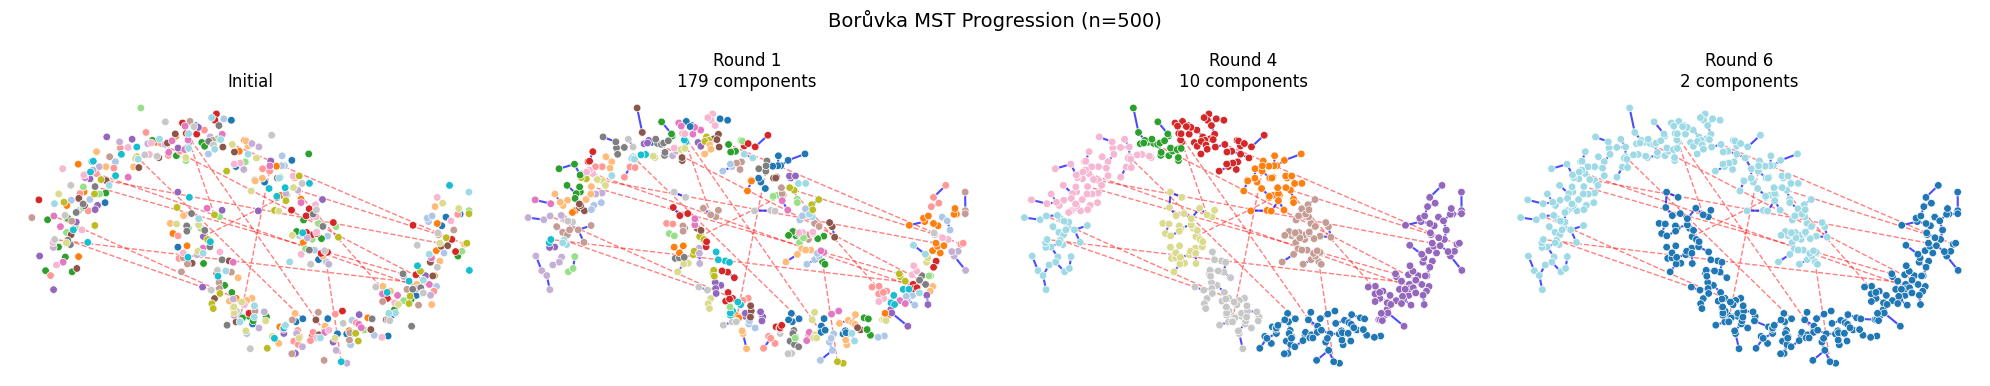

In [14]:
# Show key frames for 500 point dataset
size = 500
data = datasets['two_moons_inter'][size]
result = instrumented_results[size]

# Select frames to show: initial, middle, final
n_rounds = result.total_rounds
frame_indices = [0, n_rounds // 2, n_rounds - 1] if n_rounds > 2 else list(range(n_rounds))

fig, axes = plt.subplots(1, len(frame_indices) + 1, figsize=(5 * (len(frame_indices) + 1), 4))

# Initial state
initial_parent = np.arange(size, dtype=np.int32)
plot_graph_state(axes[0], data['X'], np.array([]).reshape(0, 3), 
                data['constraints'], initial_parent, "Initial")

# Selected rounds
for idx, round_idx in enumerate(frame_indices):
    rs = result.round_states[round_idx]
    title = f"Round {rs.round_number + 1}\n{rs.n_components} components"
    plot_graph_state(axes[idx + 1], data['X'], rs.mst_edges, 
                    data['constraints'], rs.parent, title)

plt.suptitle(f"Borůvka MST Progression (n={size})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 12. Timing Breakdown (Per-Step Analysis)

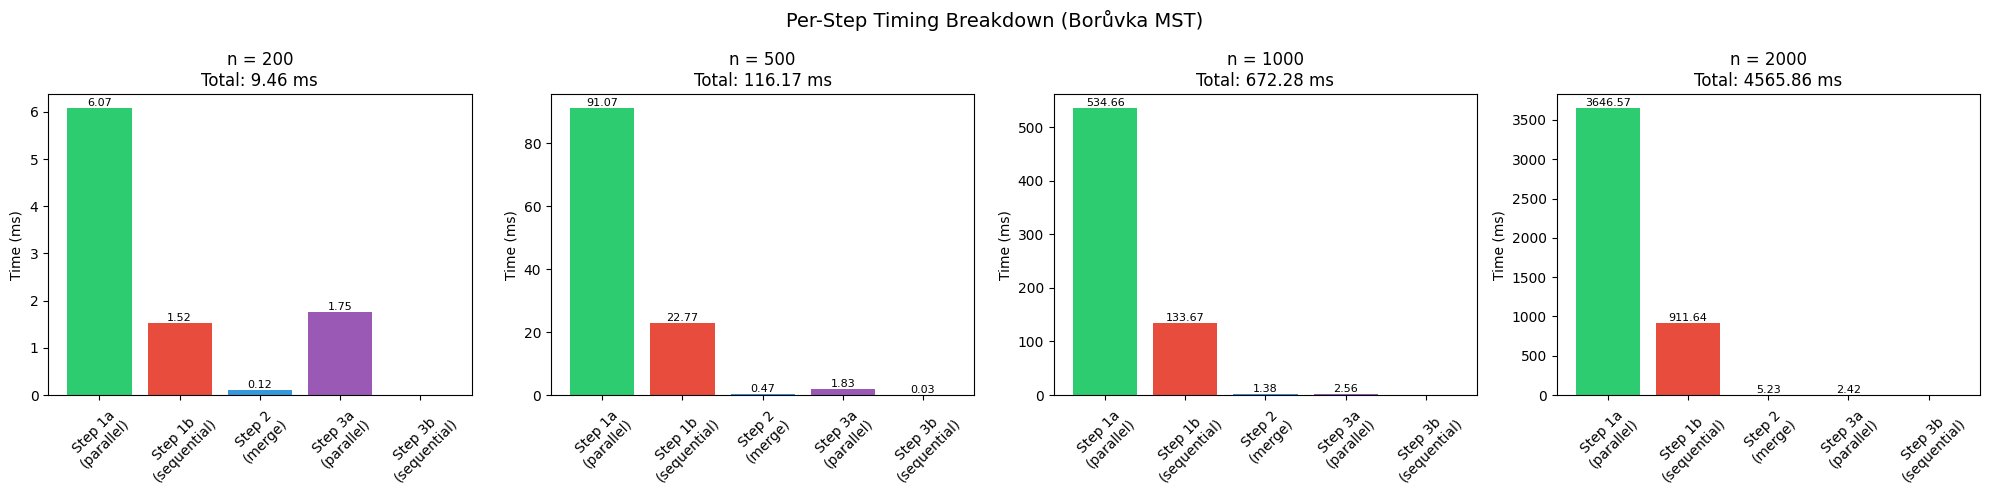

In [15]:
# Plot timing breakdown for each visualization size
plot_sizes = [s for s in VIZ_SIZES if s in instrumented_results]
n_plots = min(4, len(plot_sizes))  # Limit to 4 plots

fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
if n_plots == 1:
    axes = [axes]

step_labels = ['Step 1a\n(parallel)', 'Step 1b\n(sequential)', 'Step 2\n(merge)', 
               'Step 3a\n(parallel)', 'Step 3b\n(sequential)']
colors = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6', '#f39c12']

for idx, size in enumerate(plot_sizes[:n_plots]):
    result = instrumented_results[size]
    breakdown = result.timing_breakdown()
    
    values = [breakdown['step1a'] * 1000, breakdown['step1b'] * 1000,
              breakdown['step2'] * 1000, breakdown['step3a'] * 1000, 
              breakdown['step3b'] * 1000]
    
    bars = axes[idx].bar(step_labels, values, color=colors)
    axes[idx].set_ylabel('Time (ms)')
    axes[idx].set_title(f'n = {size}\nTotal: {result.total_time*1000:.2f} ms')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        if val > 0.01:
            axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                          f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Per-Step Timing Breakdown (Borůvka MST)', fontsize=14)
plt.tight_layout()
plt.show()

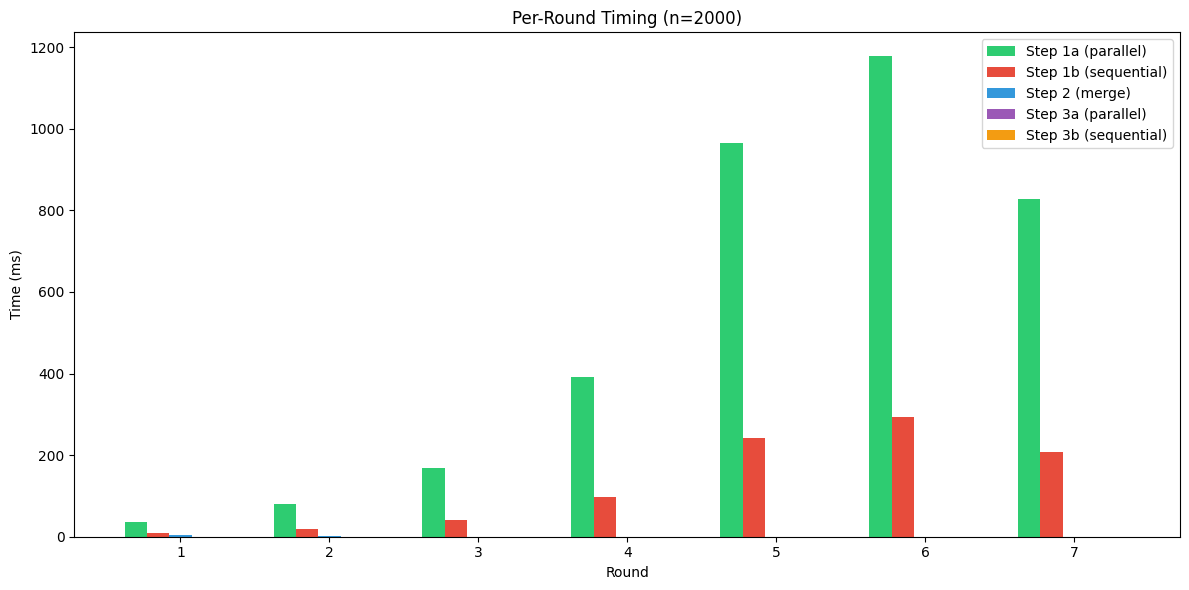

In [16]:
# Per-round timing for largest visualization size
size = max(VIZ_SIZES)
if size in instrumented_results:
    result = instrumented_results[size]

    rounds = list(range(1, result.total_rounds + 1))
    step1a_times = [rs.timing.step1a_seconds * 1000 for rs in result.round_states]
    step1b_times = [rs.timing.step1b_seconds * 1000 for rs in result.round_states]
    step2_times = [rs.timing.step2_seconds * 1000 for rs in result.round_states]
    step3a_times = [rs.timing.step3a_seconds * 1000 for rs in result.round_states]
    step3b_times = [rs.timing.step3b_seconds * 1000 for rs in result.round_states]

    fig, ax = plt.subplots(figsize=(12, 6))

    width = 0.15
    x = np.arange(len(rounds))

    ax.bar(x - 2*width, step1a_times, width, label='Step 1a (parallel)', color='#2ecc71')
    ax.bar(x - width, step1b_times, width, label='Step 1b (sequential)', color='#e74c3c')
    ax.bar(x, step2_times, width, label='Step 2 (merge)', color='#3498db')
    ax.bar(x + width, step3a_times, width, label='Step 3a (parallel)', color='#9b59b6')
    ax.bar(x + 2*width, step3b_times, width, label='Step 3b (sequential)', color='#f39c12')

    ax.set_xlabel('Round')
    ax.set_ylabel('Time (ms)')
    ax.set_title(f'Per-Round Timing (n={size})')
    ax.set_xticks(x)
    ax.set_xticklabels(rounds)
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()
else:
    print(f"Size {size} not in instrumented_results")

## 13. Borůvka Scaling Analysis

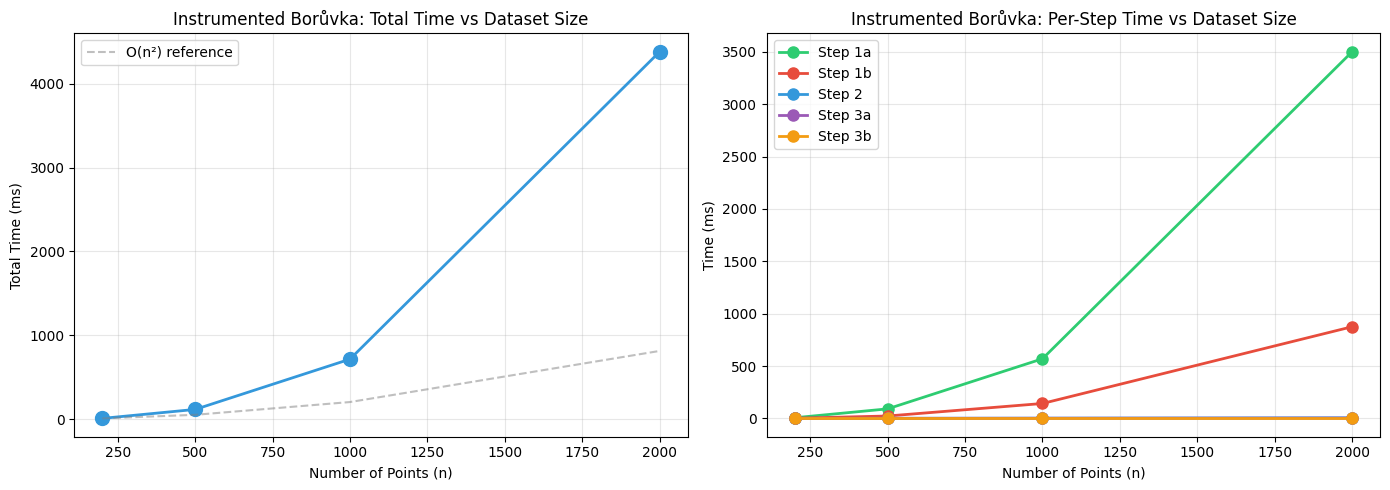


INSTRUMENTED BORŮVKA SCALING SUMMARY
Size       Rounds     Total (ms)      MST Edges    CL Removed  
----------------------------------------------------------------------
200        5          8.13            198          0           
500        6          115.13          498          0           
1000       6          715.08          998          0           
2000       7          4383.92         1997         0           


In [27]:
# Instrumented Borůvka scaling analysis: time vs n
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sizes = list(instrumented_results.keys())
total_times = [instrumented_results[s].total_time * 1000 for s in sizes]
n_rounds = [instrumented_results[s].total_rounds for s in sizes]

# Total time scaling
axes[0].plot(sizes, total_times, 'o-', markersize=10, linewidth=2, color='#3498db')
axes[0].set_xlabel('Number of Points (n)')
axes[0].set_ylabel('Total Time (ms)')
axes[0].set_title('Instrumented Borůvka: Total Time vs Dataset Size')
axes[0].grid(True, alpha=0.3)

# Add quadratic reference line
if len(sizes) > 0:
    n_ref = np.array(sizes)
    scale = total_times[0] / (sizes[0] ** 2)
    axes[0].plot(n_ref, scale * n_ref ** 2, '--', color='gray', alpha=0.5, label='O(n²) reference')
    axes[0].legend()

# Per-step breakdown scaling
step_keys = ['step1a', 'step1b', 'step2', 'step3a', 'step3b']
step_names = ['Step 1a', 'Step 1b', 'Step 2', 'Step 3a', 'Step 3b']
colors = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6', '#f39c12']

for key, name, color in zip(step_keys, step_names, colors):
    times = [instrumented_results[s].timing_breakdown()[key] * 1000 for s in sizes]
    axes[1].plot(sizes, times, 'o-', markersize=8, linewidth=2, color=color, label=name)

axes[1].set_xlabel('Number of Points (n)')
axes[1].set_ylabel('Time (ms)')
axes[1].set_title('Instrumented Borůvka: Per-Step Time vs Dataset Size')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*70)
print("INSTRUMENTED BORŮVKA SCALING SUMMARY")
print("="*70)
print(f"{'Size':<10} {'Rounds':<10} {'Total (ms)':<15} {'MST Edges':<12} {'CL Removed':<12}")
print("-"*70)
for size in sizes:
    r = instrumented_results[size]
    print(f"{size:<10} {r.total_rounds:<10} {r.total_time*1000:<15.2f} {len(r.final_mst):<12} {len(r.cannot_link_edges):<12}")

## 14. Component Count Over Rounds

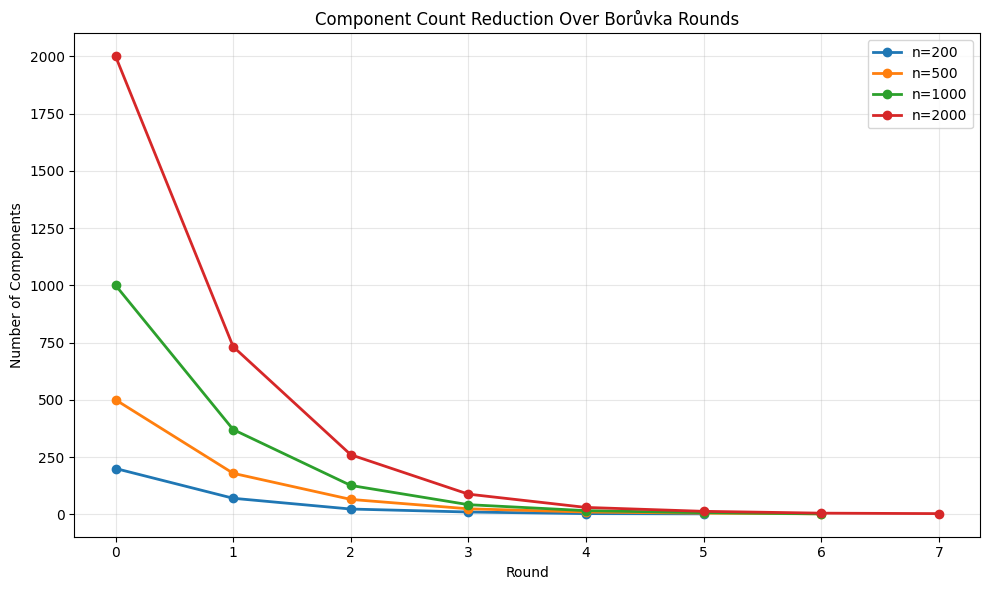

In [18]:
# Show how component count decreases over rounds
fig, ax = plt.subplots(figsize=(10, 6))

for size in VIZ_SIZES:
    if size in instrumented_results:
        result = instrumented_results[size]
        rounds = [0] + [rs.round_number + 1 for rs in result.round_states]
        components = [size] + [rs.n_components for rs in result.round_states]
        ax.plot(rounds, components, 'o-', markersize=6, linewidth=2, label=f'n={size}')

ax.set_xlabel('Round')
ax.set_ylabel('Number of Components')
ax.set_title('Component Count Reduction Over Borůvka Rounds')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:

### Datasets
- **Two Moons with Inter-class Constraints**: Standard cannot-link between different clusters
- **Two Moons with Intra-class Constraints**: Adversarial constraints within same cluster  
- **Y-Shape with Tip Constraints**: Three-branch data with tip-to-tip constraints

### Comparisons (4 Methods)
1. **Constrained HDBSCAN (Borůvka)**: Our implementation with cannot-link constraints
2. **Constrained HDBSCAN (no constraints)**: Baseline without constraints
3. **fast_hdbscan + Kruskal**: Using constrained Kruskal MST
4. **Standard HDBSCAN**: Reference implementation (capped at 2000 points)

### Metrics
- **ARI, NMI, V-measure**: Clustering quality vs ground truth
- **Timing**: Scaling from 200 to 10,000 points

### Visualization
- Frame-by-frame Borůvka MST animation
- Per-step timing breakdown
- Scaling plots across all sizes
- Side-by-side cluster comparisons